In [1]:
!pip install opencv-contrib-python scikit-image matplotlib numpy

  Obtaining dependency information for opencv-contrib-python from https://files.pythonhosted.org/packages/8b/39/f87d154d2dca8e9815ca9e4f925aee41e5931162da730d17f3200e7786f3/opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for scikit-image from https://files.pythonhosted.org/packages/f4/a2/70401a107d6d7466d64b466927e6b96fcefa99d57494b972608e2f8be50f/scikit_image-0.26.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for scipy>=1.11.4 from https://files.pythonhosted.org/packages/df/64/ff35eb9e54894cf471ff4716abd3c81eb0a0626869217ce3e6ba4ccf17d7/scipy-1.18.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 387.5 kB/s eta 0:00:00a 0:00:01
  Obtaining dependency information for networkx>=3.0 from https://files.pythonhosted.org/packages/9e/c9/b2622292ea83fbb4ec318f5b9ab867d0a28ab43c5717bb85b0a5f6b3b

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

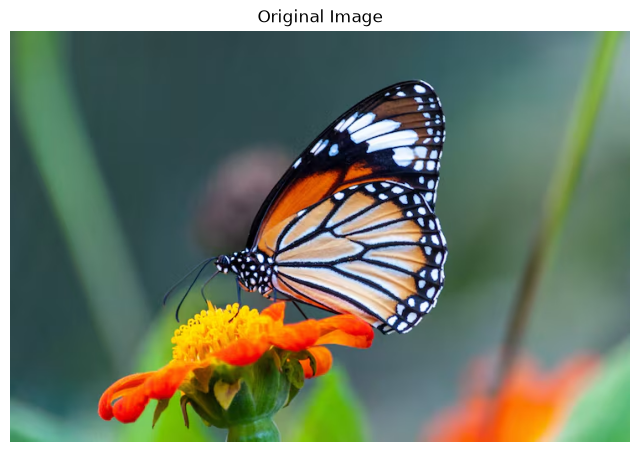

In [5]:
image = cv2.imread("butterfly.avif")

# Convert BGR to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [21]:
cv2.imwrite("original.jpg", image)

True

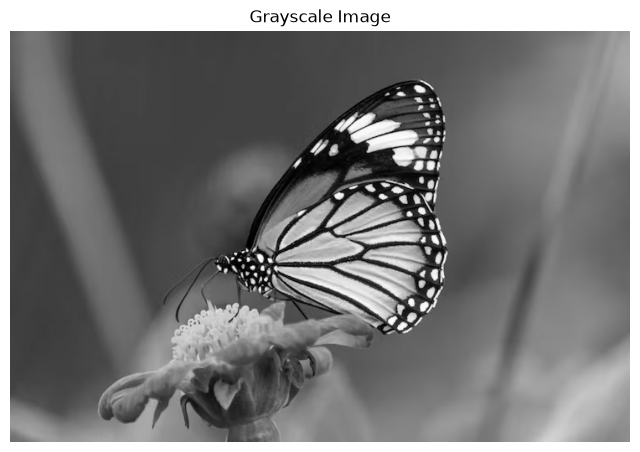

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [23]:
cv2.imwrite("grayscale.jpg", gray)

True

In [7]:
sift = cv2.SIFT_create()

In [8]:
keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)

Number of keypoints: 1026
Descriptor shape: (1026, 128)


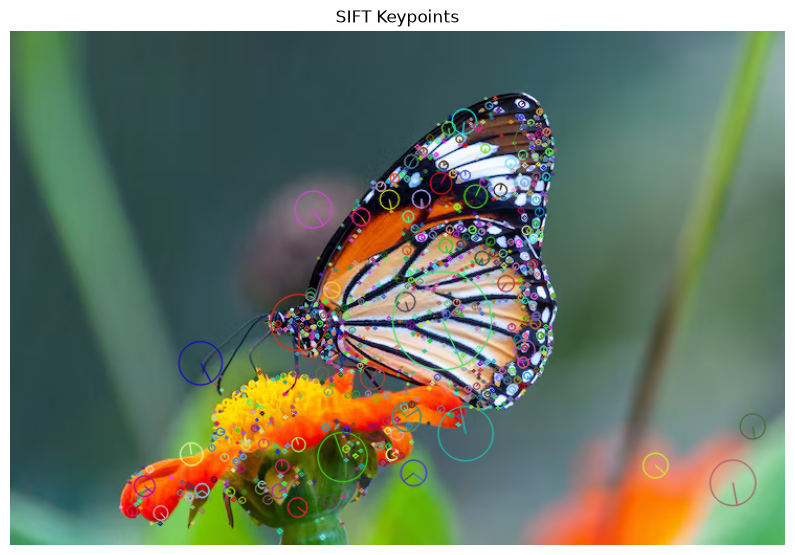

In [9]:
sift_image = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 7))
plt.imshow(sift_image)
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

In [24]:
cv2.imwrite("siftImg.jpg",sift_image )

True

In [10]:
print("Number of keypoints:", len(keypoints))
print("Descriptor dimensions:", descriptors.shape[1])

Number of keypoints: 1026
Descriptor dimensions: 128


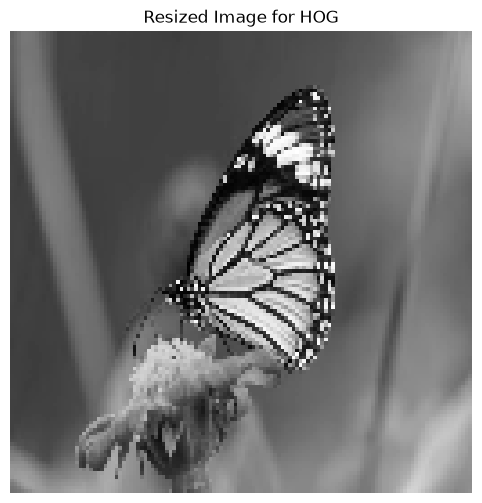

In [11]:
hog_image = cv2.resize(gray, (128, 128))

plt.figure(figsize=(6, 6))
plt.imshow(hog_image, cmap="gray")
plt.title("Resized Image for HOG")
plt.axis("off")
plt.show()

In [25]:
cv2.imwrite("hogImg.jpg", hog_image)

True

In [12]:
features, hog_visualization = hog(
    hog_image,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    block_norm='L2-Hys'
)

In [13]:
print("Number of HOG features:", len(features))

Number of HOG features: 8100


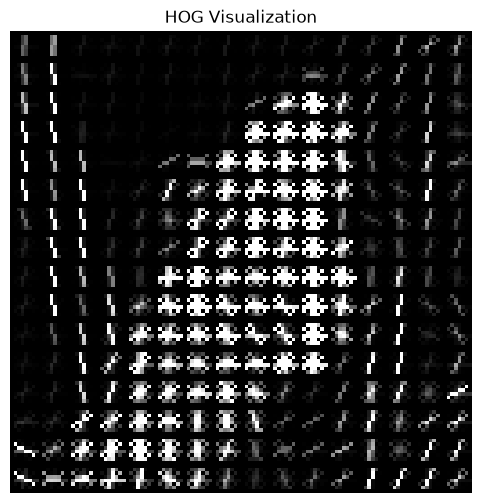

In [14]:
hog_visualization_rescaled = exposure.rescale_intensity(
    hog_visualization,
    in_range=(0, 10)
)

plt.figure(figsize=(8, 6))
plt.imshow(hog_visualization_rescaled, cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")
plt.show()

In [27]:
cv2.imwrite("hogVisualization.jpg", hog_visualization_rescaled)

True

In [35]:
image2 = cv2.imread("butterfly2.jpg")

In [36]:
cv2.imwrite("similar.jpg", image2)

True

In [15]:
img1 = cv2.imread("butterfly.avif", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("butterfly2.jpg", cv2.IMREAD_GRAYSCALE)

print(img1.shape)
print(img2.shape)

(491, 740)
(414, 738)


In [16]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print("Image 1 keypoints:", len(kp1))
print("Image 2 keypoints:", len(kp2))

Image 1 keypoints: 1026
Image 2 keypoints: 1497


In [17]:
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

In [18]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

Good matches: 18


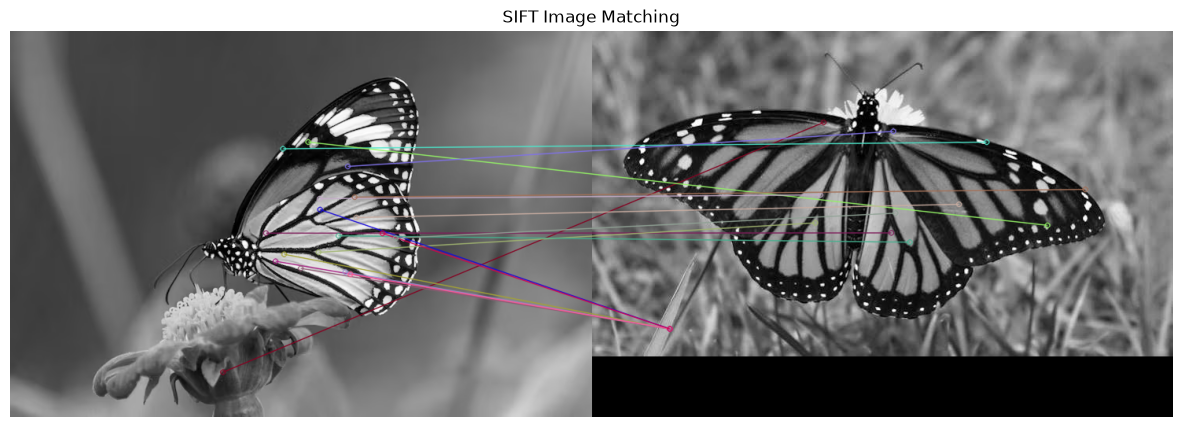

In [19]:
matched_image = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 8))
plt.imshow(matched_image, cmap="gray")
plt.title("SIFT Image Matching")
plt.axis("off")
plt.show()

In [28]:
cv2.imwrite("matchedImg.jpg", matched_image)

True